In [1]:
import networkx as nx
a_map = dict()
a_map[0]='a'
a_map[5] = 'b'
print(a_map.keys())

dict_keys([0, 5])


In [2]:
print(type(list(a_map.keys())))

<class 'list'>


What we want to do are:
1. A fast subgraph isomorphism that can detect if a pattern graph is embeddable into the target graph;
2. Suppose we have transformed a part of the circuit and the current mapping is deonted as preMap. Then we want to find a mapping for the next section of the circuit whose interaction graph is embeddable in AG. Naturally we require the embedding should be as close to preMap as possible, which implies that the number of SWAPs required is minimal. Note that there is no reason to fix the section. Instead, we may only consider a part of the section so that the SWAP gates required in total is minimal.
3. For topgraph initial mapping, we may request the embedding has a small distance with the rest of the circuits: dist(curMap, GATES) = sum(dist(curMap[gate[0]],curMap[gate[1]])).
4. We could scan the circuit layer by layer and find the largest chunk that is embeddable.
5. Reconsider the weighted interaction graph. We now consider the distribution of each edge and use this to characterise the interaction graph.
6. Given a circuit, we could first slice it into chunks s.t. each chunk contains several layers and its interaction graph is embeddable to AG. For a central chunk, we could generate an embedding which has a small distance with a weighted graph mapping for the rest of the circuit. 

DiGraph with 13 nodes and 13 edges


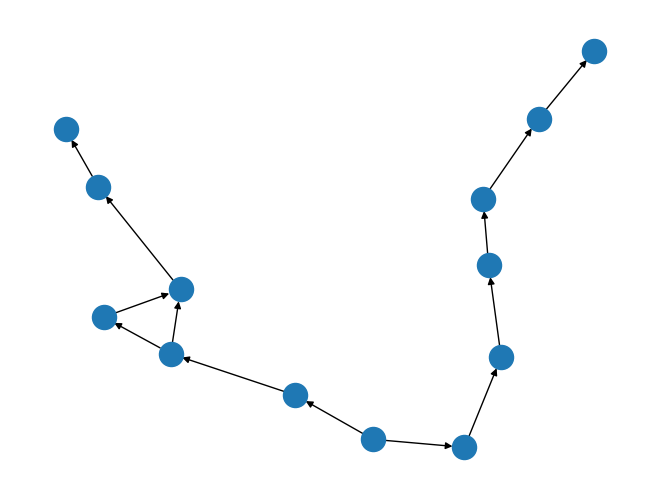

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add nodes
G.add_node('Beijing', pos=(0, 0))
G.add_node('Tianjin', pos=(1, 0))
G.add_node('Shijiazhuang', pos=(2, 2))
G.add_node('Zhengzhou', pos=(4, 4))
G.add_node('Jinan', pos=(4, 1))
G.add_node('Qingdao', pos=(7, 1))
G.add_node('Nanjing', pos=(9, 3))
G.add_node('Shanghai', pos=(11, 2))
G.add_node('Hangzhou', pos=(12, 0))
G.add_node('Wuhan', pos=(6, 0))
G.add_node('Changsha', pos=(7, -2))
G.add_node('Guangzhou', pos=(13, -2))
G.add_node('Shenzhen', pos=(14, -1))

# Add edges
G.add_edge('Beijing', 'Tianjin', distance=117)
G.add_edge('Beijing', 'Shijiazhuang', distance=270)
G.add_edge('Tianjin', 'Jinan', distance=440)
G.add_edge('Shijiazhuang', 'Zhengzhou', distance=395)
G.add_edge('Jinan', 'Qingdao', distance=440)
G.add_edge('Zhengzhou', 'Wuhan', distance=530)
G.add_edge('Jinan', 'Nanjing', distance=600)
G.add_edge('Qingdao', 'Nanjing', distance=800)
G.add_edge('Nanjing', 'Shanghai', distance=300)
G.add_edge('Shanghai', 'Hangzhou', distance=200)
G.add_edge('Wuhan', 'Changsha', distance=350)
G.add_edge('Changsha', 'Guangzhou', distance=660)
G.add_edge('Guangzhou', 'Shenzhen', distance=100)

print(G)

# Draw the graph
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'distance')
#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
nx.draw(G, pos, font_size=8)
plt.show()